In [2]:
!pip install ta

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29481 sha256=6711a65794ff8801bcca4b9a28802ee98805561b64be4f485a1d9bf3886071d2
  Stored in directory: /tmp/pip-ephem-wheel-cache-_gruvova/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import sys
from pathlib import Path

import sys
sys.path.insert(0, '/app')
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
import pandas as pd
import ta
import matplotlib.pyplot as plt
import numpy as np
from numba import njit
import sys
import os

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [106]:
@njit
def smma_numba(p_src, p_length):
    """
    Calculates the Smoothed Moving Average (SMMA) of a source array.

    Parameters:
        p_src (array): The source data (numpy array).
        length (int): The period of the SMMA.

    Returns:
        array: The SMMA values.
    """
    smma = np.zeros(len(p_src))
    for i in range(len(p_src)):
        if i == 0:
            smma[i] = p_src[0]  # SMA for the first value
        else:
            smma[i] = (smma[i - 1] * (p_length - 1) + p_src[i]) / p_length
    return smma


# Define the CTO Line function
def cto_line(p_data, p_param = (15,19,25,29), isnum = False):
    
    p_data['hl2'] = (p_data['High'] + p_data['Low']) / 2
    h12 = p_data['hl2'].to_numpy()
    v1 = smma_numba(h12, p_param[0])
    m1 = smma_numba(h12, p_param[1])
    m2 = smma_numba(h12, p_param[2])
    v2 = smma_numba(h12, p_param[3])

    p2 = ((v1 < m1) != (v1 < v2)) | ((m2 < v2) != (v1 < v2))
    p3 = ~(p2) & (v1 < v2)
    p1 = ~(p2) & ~(p3)


    # Define color mappings
    if isnum:
        color_orange = 1
        color_silver = 0
        color_navy = -1
    else:
        color_orange = 'orange'
        color_silver = 'silver'
        color_navy = 'navy'

    # Apply conditional logic with np.where
    c = np.where(p1, color_orange, np.where(p2, color_silver, color_navy))
        
    p_data['color'] = c
    p_data['Line 1'] = v1
    p_data['Line 2'] = v2

    return p_data

# Define the trading strategy
def cto_strategy(p_data):
    # Calculate the CTO Line
    p_data = cto_line(p_data)

    # Initialize the strategy
    p_data['Signal'] = 0
    p_data['Position'] = 0

    # Generate signals
    p_data.loc[p_data['color'] == 'orange', 'Signal'] = 1  # Buy signal
    p_data.loc[p_data['color'] == 'navy', 'Signal'] = -1   # Sell signal

    # Calculate the strategy returns
    p_data['Returns'] = p_data['Signal'].shift(1) * p_data['Close'].pct_change()
    p_data['ReturnsMkt'] = p_data['Close'].pct_change()
    
    # Calculate the data returns
    p_data['ReturnsClose'] = p_data['Close'].pct_change()

    
    return p_data

def plot_ribbon_chart_1(df, x_label="X-axis", y_label="Y-axis", title="CTO line"):
    """
    Plots a ribbon chart from a DataFrame with 'line1', 'line2', and 'colour' columns.

    Parameters:
        df (pd.DataFrame): DataFrame with 'line1', 'line2', and 'colour' columns.
        x_label (str): Label for the X-axis.
        y_label (str): Label for the Y-axis.
        title (str): Title of the chart.

    Returns:
        None
    """
    # Check if required columns exist
    required_columns = {'Line 1', 'Line 2', 'color'}
    if not required_columns.issubset(df.columns):
        raise ValueError(f"DataFrame must contain columns: {required_columns}")
    
    # Plot setup
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Plot ribbons
    for i in range(len(df) - 1):
        x = df.index[i:i + 2]
        y1 = [df['Line 1'].iloc[i], df['Line 1'].iloc[i + 1]]
        y2 = [df['Line 2'].iloc[i], df['Line 2'].iloc[i + 1]]
        ax.fill_between(x, y1, y2, color=df['color'].iloc[i], alpha=0.6)
    
    # Add labels and title

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    
    ax.plot(df['Close'])

    ax2 = ax.twinx()
    ax2.plot(df['Returns'].cumsum(), color='red')

    # Show the plot
    plt.show()

def plot_ribbon_chart(df, x_label="X-axis", y_label="Y-axis", title="CTO line"):
    """
    Plots a ribbon chart from a DataFrame with 'line1', 'line2', and 'colour' columns.

    Parameters:
        df (pd.DataFrame): DataFrame with 'line1', 'line2', and 'colour' columns.
        x_label (str): Label for the X-axis.
        y_label (str): Label for the Y-axis.
        title (str): Title of the chart.

    Returns:
        None
    """
    # Check if required columns exist
    required_columns = {'Line 1', 'Line 2', 'color'}
    if not required_columns.issubset(df.columns):
        raise ValueError(f"DataFrame must contain columns: {required_columns}")
    
    # Plot setup
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # Plot ribbons
    for i in range(len(df) - 1):
        x = df.index[i:i + 2]
        y1 = [df['Line 1'].iloc[i], df['Line 1'].iloc[i + 1]]
        y2 = [df['Line 2'].iloc[i], df['Line 2'].iloc[i + 1]]
        ax.fill_between(x, y1, y2, color=df['color'].iloc[i], alpha=0.6)
    
    # Add labels and title

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    
    ax.plot(df['Close'])

    # Show the plot
    plt.show()

In [ ]:
import pandas as pd
import numpy as np

from core.data_org import BUNDLE_DIR
from strat.strat_macd_ema import (
    build_features,
    MACDEMA_SwingOrATR,
    split_and_optimize,
    run_backtest,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [6]:
def convert_framework_columns_to_ohlcv(df, prefix=None):
    """
    Convert framework column format to standard OHLCV format.
    
    Framework uses: S_close_f32, S_open_f32, etc.
    Strategy expects: Close, Open, High, Low, Volume
    """
    ohlcv_df = pd.DataFrame(index=df.index)
    
    if prefix and f"{prefix}_S_close_f32" in df.columns:
        ohlcv_df["Close"] = df[f"{prefix}_S_close_f32"]
        ohlcv_df["Open"] = df[f"{prefix}_S_open_f32"]
        ohlcv_df["High"] = df[f"{prefix}_S_high_f32"]
        ohlcv_df["Low"] = df[f"{prefix}_S_low_f32"]
        ohlcv_df["Volume"] = df[f"{prefix}_S_volume_f64"]
    elif "S_close_f32" in df.columns:
        ohlcv_df["Close"] = df["S_close_f32"]
        ohlcv_df["Open"] = df["S_open_f32"]
        ohlcv_df["High"] = df["S_high_f32"]
        ohlcv_df["Low"] = df["S_low_f32"]
        ohlcv_df["Volume"] = df["S_volume_f64"]
    else:
        for col_type, target in [
            ("close", "Close"),
            ("open", "Open"),
            ("high", "High"),
            ("low", "Low"),
            ("volume", "Volume"),
        ]:
            matching_cols = [c for c in df.columns if f"_S_{col_type}_" in c.lower()]
            if matching_cols:
                ohlcv_df[target] = df[matching_cols[0]]
    
    # Convert time column to datetime index
    if "i_minute_i" in df.columns:
        base = pd.Timestamp("2000-01-01")
        ohlcv_df.index = base + pd.to_timedelta(df["i_minute_i"].astype(int), unit='m')
    
    return ohlcv_df.dropna()

In [7]:
ETF_SYMBOL = "QQQ"  # Options: QQQ, SPY, TLT, GLD, VWO

SPLIT_RATIO = 0.5       # Fraction of data for training
EMA_LEN = 200           # EMA period (configurable)

RR_GRID = [1.5, 2.0, 2.5]           # Risk-reward ratios to test
SW_WINDOW_GRID = [3, 5, 7]          # Swing window sizes to test

bundle_file = BUNDLE_DIR / "candle_1hour" / f"{ETF_SYMBOL}_features.parquet"

if not bundle_file.exists():
    raise FileNotFoundError(
        f"Bundle not found: {bundle_file}\n"
        f"Please run: python scripts/features/compute_etf_bundle.py"
    )

print(f"Loading {ETF_SYMBOL} from: {bundle_file}")
df_raw = pd.read_parquet(bundle_file)
print(f"Raw data shape: {df_raw.shape}")

ohlcv_df = convert_framework_columns_to_ohlcv(df_raw)
print(f"OHLCV data shape: {ohlcv_df.shape}")
print(f"Date range: {ohlcv_df.index[0]} to {ohlcv_df.index[-1]}")
ohlcv_df.head()

Loading QQQ from: /app/data/bundle/candle_1hour/QQQ_features.parquet
Raw data shape: (92274, 123)
OHLCV data shape: (92274, 5)
Date range: 2000-01-03 09:00:00 to 2026-02-26 19:00:00


,Close,Open,High,Low,Volume
i_minute_i,,,,,
2000-01-03 09:00:00,96.789284,99.871735,99.871735,96.691994,8984264.0
2000-01-03 10:00:00,95.199417,96.821793,97.957367,94.485634,9491568.0
2000-01-03 11:00:00,96.464897,95.231804,96.724388,94.226036,8086721.0
2000-01-03 12:00:00,96.189041,96.432396,96.562195,95.653709,2276071.0
2000-01-03 13:00:00,96.951591,96.253944,97.340874,95.978088,3187450.0


In [107]:
strat_cto = cto_strategy(ohlcv_df)

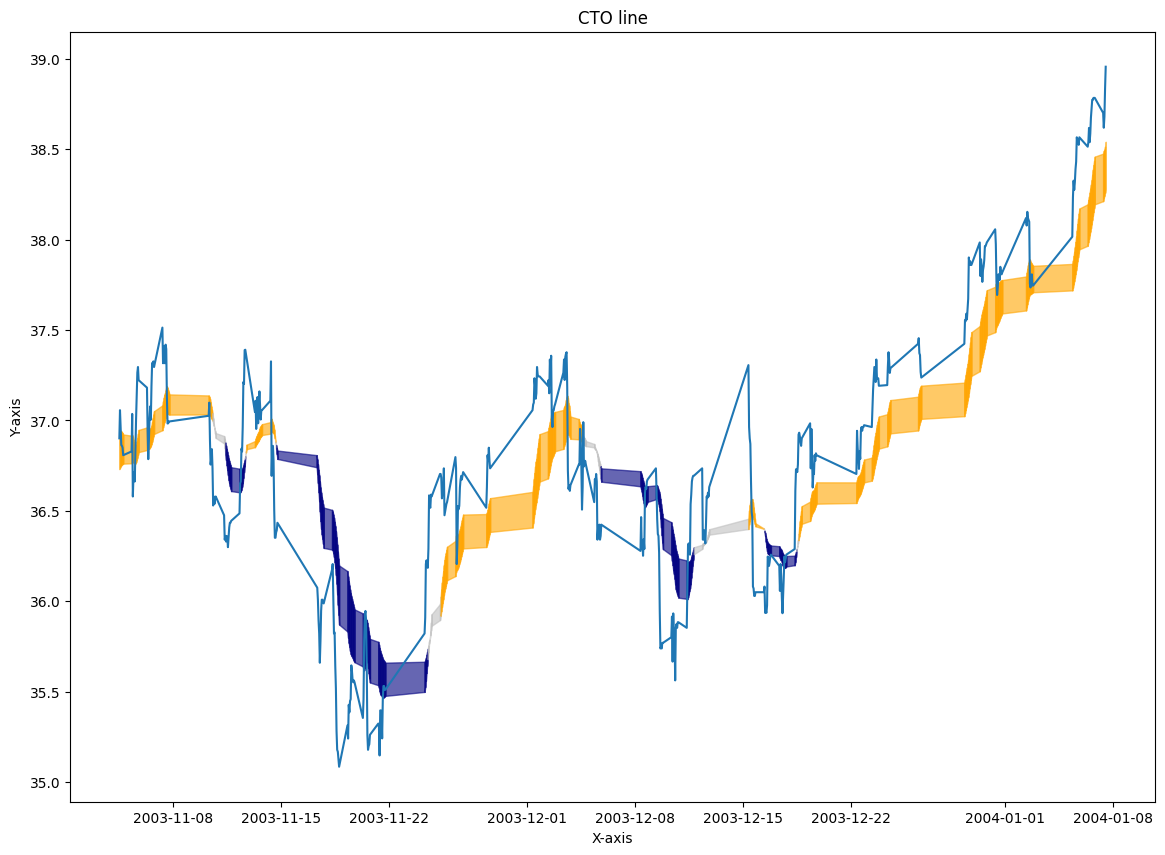

In [108]:
plot_ribbon_chart(strat_cto[10000:10500])

In [33]:
strat_cto['Returns'][1:]

i_minute_i
2000-01-03 10:00:00   -0.016426
2000-01-03 11:00:00   -0.013293
2000-01-03 12:00:00    0.002860
2000-01-03 13:00:00   -0.007928
2000-01-03 14:00:00    0.003347
                         ...   
2026-02-26 15:00:00    0.000772
2026-02-26 16:00:00   -0.002150
2026-02-26 17:00:00   -0.001151
2026-02-26 18:00:00   -0.000263
2026-02-26 19:00:00   -0.000362
Name: Returns, Length: 92273, dtype: float64

In [ ]:
(-strat_cto['Returns'][1:]).cumsum().plot()

In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

def plot_histogram_100bins(df):
    """
    Plot a 100-bin histogram between -0.03 and 0.03 for the given dataframe
    
    Parameters:
    df: pandas DataFrame with datetime index and values in the second column
    """
    # Extract the values (assuming they're in the second column)
    values = df.iloc[:, 0].values if isinstance(df, pd.DataFrame) else df.values
    
    # Create the figure and axis
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # Create histogram with 100 bins between -0.03 and 0.03
    counts, bins, patches = ax.hist(values, 
                                    bins=100, 
                                    range=(-0.03, 0.03),
                                    edgecolor='black',
                                    alpha=0.7,
                                    color='skyblue')
    
    # Customize the plot
    ax.set_xlabel('Value', fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title('100-Bin Histogram (-0.03 to 0.03)', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle='--')
    
    # Add some statistics
    mean_val = np.mean(values)
    median_val = np.median(values)
    std_val = np.std(values)
    
    # Add vertical lines for mean and median
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.6f}')
    ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.6f}')
    
    # Add legend
    ax.legend()
    
    # Tight layout
    plt.tight_layout()
    
    # Display the plot
    plt.show()
    
    # Print statistics
    print(f"Statistics for values between -0.03 and 0.03:")
    print(f"Mean: {mean_val:.6f}")
    print(f"Median: {median_val:.6f}")
    print(f"Std Dev: {std_val:.6f}")
    print(f"Min: {np.min(values):.6f}")
    print(f"Max: {np.max(values):.6f}")
    print(f"Count: {len(values)}")
    
    return fig, ax

# Example usage with your data:
# First, create the dataframe from your data
data = {
    'timestamp': ['2000-01-03 10:00:00', '2000-01-03 11:00:00', 
                  '2000-01-03 12:00:00', '2000-01-03 13:00:00', 
                  '2000-01-03 14:00:00'],
    'value': [-0.016426, -0.013293, 0.002860, -0.007928, 0.003347]
}

df = pd.DataFrame(data)
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.set_index('timestamp', inplace=True)

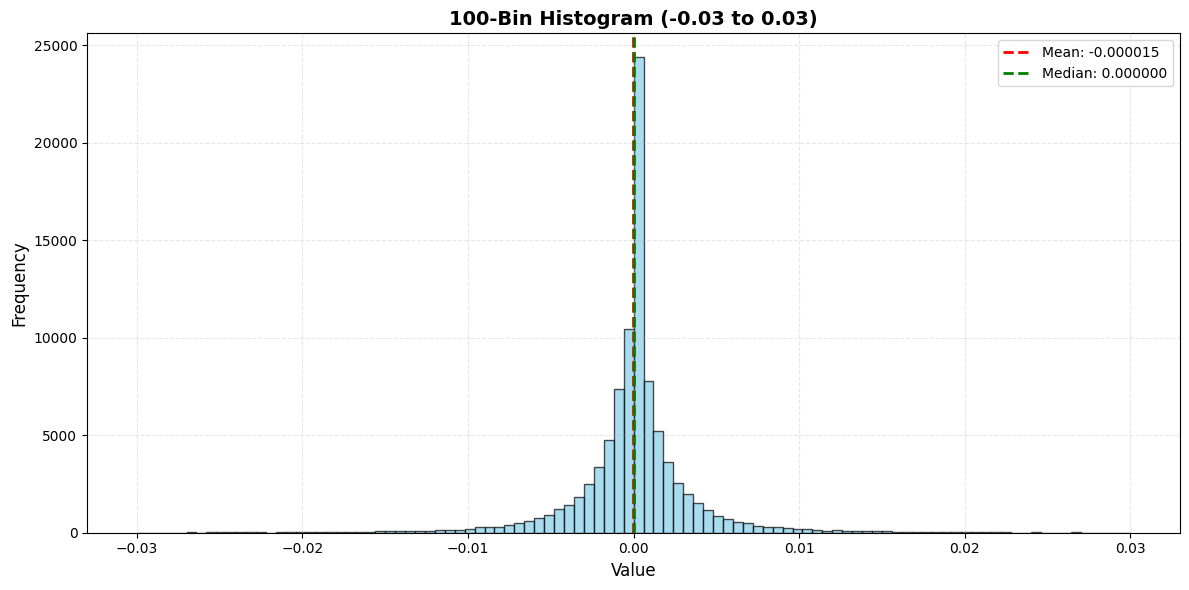

Statistics for values between -0.03 and 0.03:
Mean: -0.000015
Median: 0.000000
Std Dev: 0.004171
Min: -0.098380
Max: 0.071444
Count: 92273


(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': '100-Bin Histogram (-0.03 to 0.03)'}, xlabel='Value', ylabel='Frequency'>)

In [35]:
# Call the function
plot_histogram_100bins(strat_cto['Returns'][1:])

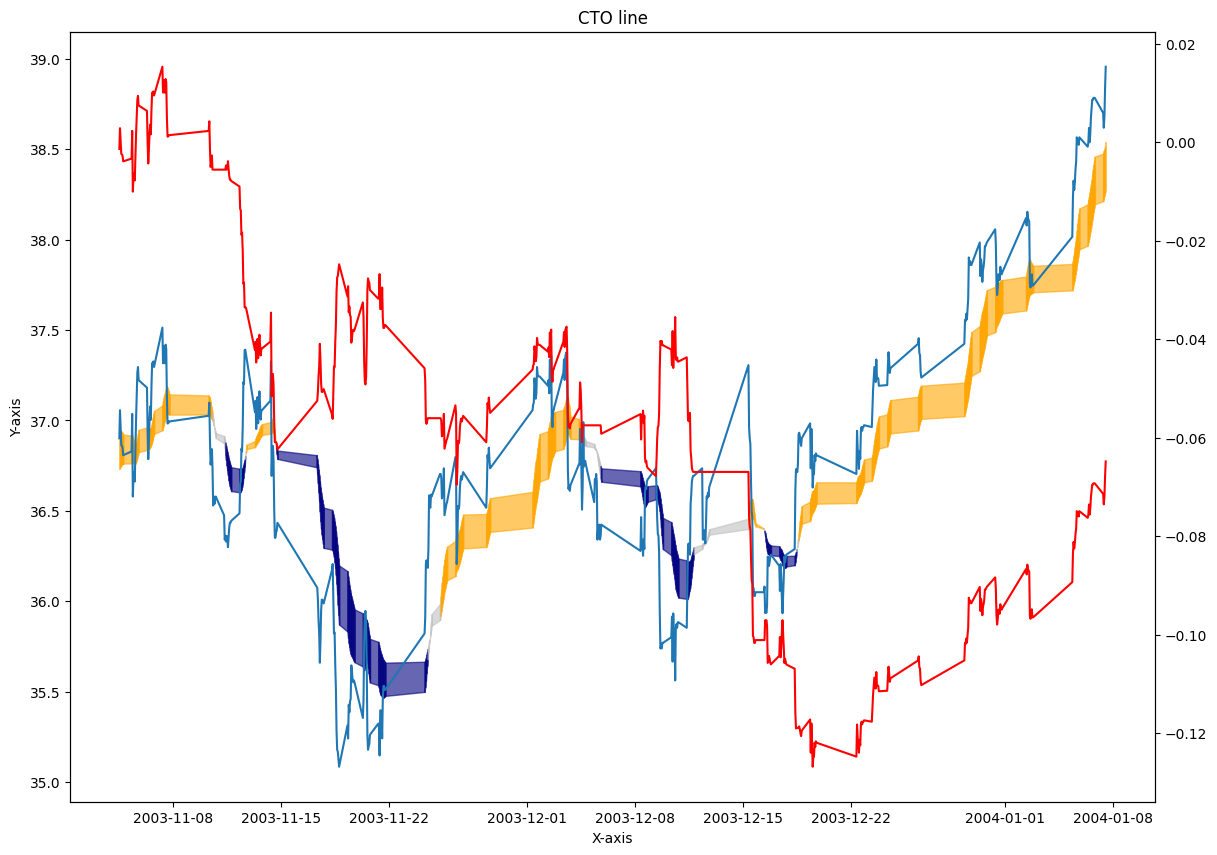

In [15]:
plot_ribbon_chart_1(strat_cto[10000:10500])

In [187]:
start = 15000
stop = 17000

strat_cto[start:stop]['Signal']

i_minute_i
2005-11-17 13:00:00    1
2005-11-17 14:00:00    1
2005-11-17 15:00:00    1
2005-11-18 09:00:00    1
2005-11-18 10:00:00    1
                      ..
2007-01-05 14:00:00    1
2007-01-05 15:00:00    1
2007-01-05 16:00:00    1
2007-01-05 17:00:00    1
2007-01-05 18:00:00    1
Name: Signal, Length: 2000, dtype: int64

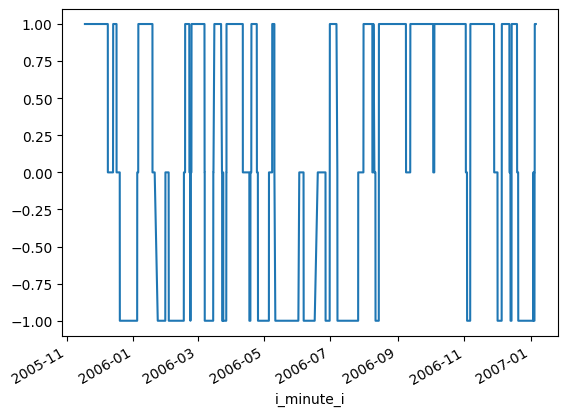

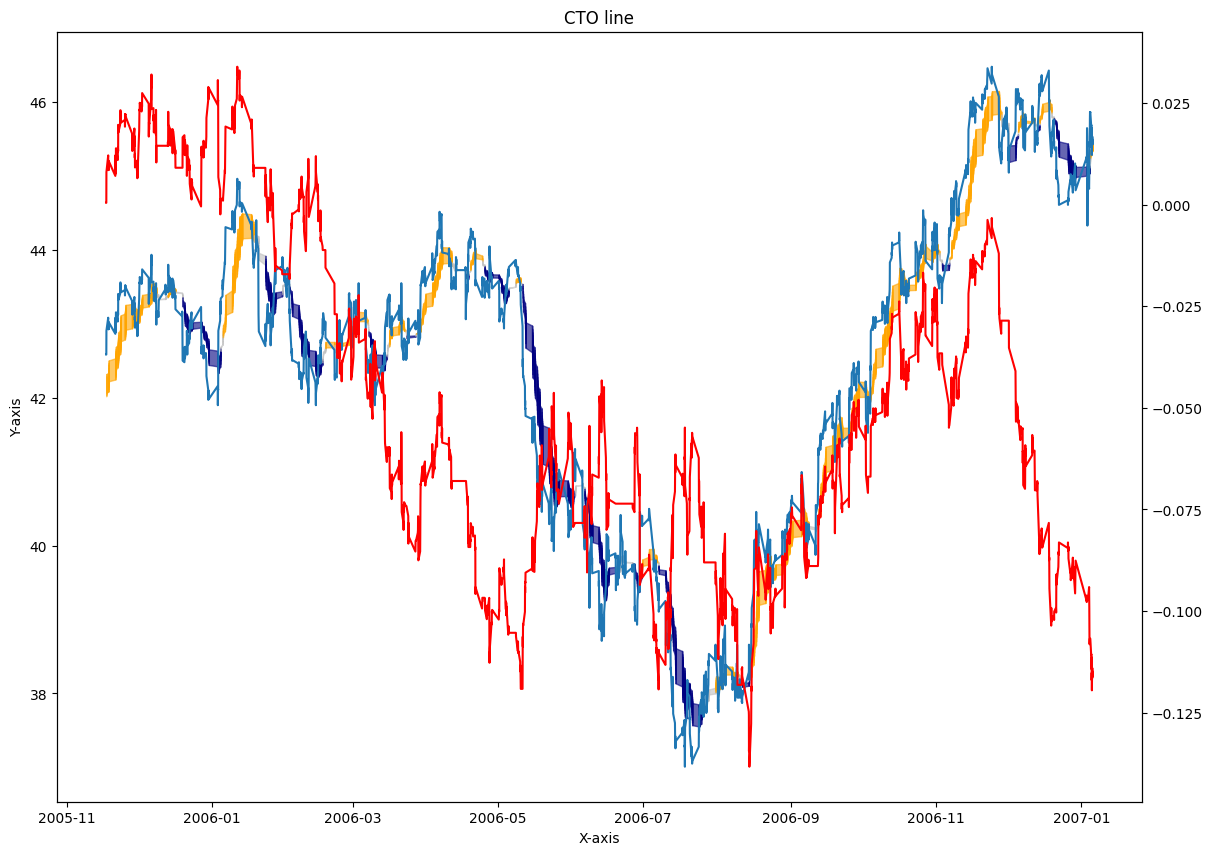

<Axes: xlabel='i_minute_i'>

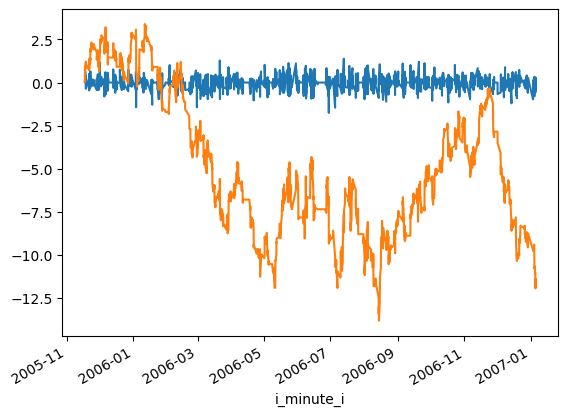

In [110]:
plot_ribbon_chart_1(strat_cto[start:stop])
(strat_cto[start:stop]['Returns']*100).plot()
(strat_cto[start:stop]['Returns'].cumsum()*100).plot()

In [ ]:
def calculate_rsi_signals(df, periods=[7,14, 21], trigger_low = 20, trigger_high = 85):
    """
    Calculate RSI for specified periods and create binary signals
    0 when RSI > 80 or RSI < 20, 1 otherwise
    
    Parameters:
    df: DataFrame with 'close' prices
    periods: list of RSI periods to calculate
    
    Returns:
    DataFrame with RSI columns and signal columns
    """
    # Create a copy to avoid modifying original
    df_result = df.copy()
    
    for period in periods:
        # Calculate RSI using ta library
        rsi_col = f'rsi_{period}'
        df_result[rsi_col] = ta.momentum.RSIIndicator(close=df_result['Close'], window=period).rsi()
        
        # Create signal column (0 when RSI > 80 or < 20, 1 otherwise)
        signal_col = f'rsi_{period}_signal'
        signal_col_no = f'rsi_{period}_signal_no'
        df_result[signal_col] = 1  # Default to 1
        df_result[signal_col_no] = 1  # Default to 1
        
        # Set to 0 when conditions are met
        df_result.loc[df_result[rsi_col] > trigger_high, signal_col] = 0
        df_result.loc[df_result[rsi_col] < trigger_low, signal_col] = 0


        df_result.loc[df_result[rsi_col] > trigger_high, signal_col_no] = -1
        df_result.loc[df_result[rsi_col] < trigger_low, signal_col_no] = -1

        # Note: When both conditions are false, it remains 1
        # For RSI exactly at 80 or 20, you might want to adjust:
        # df_result.loc[df_result[rsi_col] >= 80, signal_col] = 0
        # df_result.loc[df_result[rsi_col] <= 20, signal_col] = 0
        df_result[signal_col] = df_result[signal_col].shift(1)
        df_result[signal_col_no] = df_result[signal_col_no].shift(1)
    
    return df_result

# Calculate RSI and signals

start = 100
stop = 60000

df_with_signals = calculate_rsi_signals(strat_cto[start:stop], periods=[7,14, 21])
df_with_signals['RSI_ret']= df_with_signals['rsi_14_signal']*df_with_signals['Returns']
df_with_signals['RSI_ret_no']= df_with_signals['rsi_14_signal_no']*df_with_signals['Returns']

(df_with_signals[start:stop]['RSI_ret_no'].cumsum()).plot()
(df_with_signals[start:stop]['Returns'].cumsum()).plot()
#df_with_signals[start:stop]['rsi_7_signal'].plot()

Hourly Seasonality - Average Values by Day and Hour:
hour             3         4         5         6         7         8   \
day_name                                                                
Monday     0.000000 -0.000288  0.000171  0.000016 -0.000097  0.000043   
Tuesday    0.000000 -0.000317  0.000062 -0.000069 -0.000175 -0.000331   
Wednesday -0.002776  0.000117 -0.000053  0.000043 -0.000107  0.000103   
Thursday   0.000000 -0.000098  0.000446 -0.000056  0.000023 -0.000306   
Friday     0.000000 -0.000048  0.000332  0.000041  0.000007  0.000072   

hour             9         10        11        12        13        14  \
day_name                                                                
Monday     0.000312  0.000331  0.000275 -0.000092  0.000241 -0.000302   
Tuesday   -0.000666  0.000221 -0.000026  0.000116 -0.000066  0.000032   
Wednesday -0.000027 -0.000326 -0.000033  0.000119 -0.000345 -0.000234   
Thursday  -0.000034  0.000190 -0.000006  0.000186 -0.000009  0.000039 

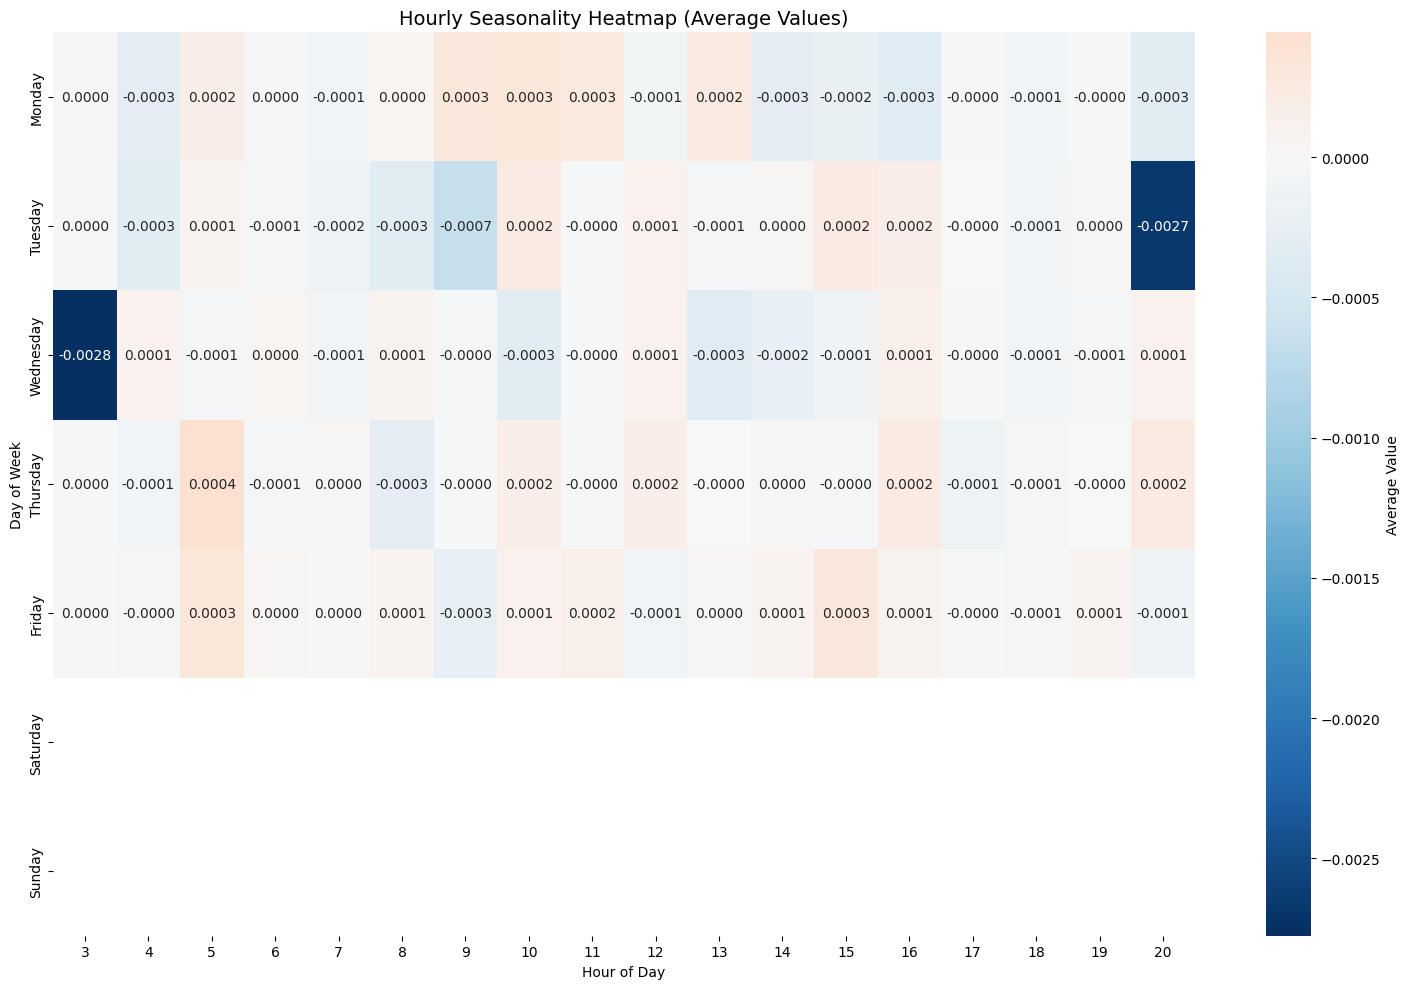


SUMMARY STATISTICS:

Daily Averages:
               mean       std  count
day_name                            
Monday     0.000003  0.004465  11266
Tuesday   -0.000047  0.004437  12284
Wednesday -0.000070  0.004629  12287
Thursday   0.000021  0.004386  12052
Friday     0.000048  0.004391  11911

Hourly Averages (all days):
          mean       std  count
hour                           
3    -0.002776       NaN      1
4    -0.000130  0.005850   2123
5     0.000190  0.002293   2093
6    -0.000006  0.002212   2540
7    -0.000070  0.002157   2793
8    -0.000086  0.003695   3364
9    -0.000142  0.006821   4534
10    0.000102  0.006317   4534
11    0.000070  0.004583   4535
12    0.000048  0.003830   4535
13   -0.000034  0.004397   4533
14   -0.000075  0.005279   4523
15    0.000040  0.006339   4519
16    0.000070  0.003583   4017
17   -0.000044  0.002368   3927
18   -0.000083  0.001608   3890
19   -0.000003  0.001028   3303
20   -0.000455  0.002239     36

Peak Hour (max value) by Day:
   

In [186]:
df_with_signals[start:stop]['Returns']

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

def display_hourly_seasonality(df, value_column=None, plot_type='line', figsize=(15, 10)):
    """
    Display hourly seasonality for each day of the week from a time series DataFrame.
    
    Parameters:
    -----------
    df : pandas DataFrame or Series
        Time series data with datetime index
    value_column : str, optional
        Name of the column containing values (if df is DataFrame)
    plot_type : str, default='line'
        Type of plot: 'line', 'heatmap', or 'box'
    figsize : tuple, default=(15, 10)
        Figure size for the plot
    
    Returns:
    --------
    pandas DataFrame
        Pivot table with days as rows and hours as columns
    """
    
    # Make a copy to avoid modifying original data
    data = df.copy()
    
    # Handle different input types
    if isinstance(data, pd.Series):
        values = data
    elif isinstance(data, pd.DataFrame):
        if value_column is None:
            # If no column specified, use the first numeric column
            numeric_cols = data.select_dtypes(include=[np.number]).columns
            if len(numeric_cols) > 0:
                value_column = numeric_cols[0]
                print(f"Using column: {value_column}")
                values = data[value_column]
            else:
                raise ValueError("No numeric columns found in DataFrame")
        else:
            values = data[value_column]
    else:
        raise TypeError("Input must be pandas DataFrame or Series")
    
    # Ensure datetime index
    if not isinstance(data.index, pd.DatetimeIndex):
        try:
            data.index = pd.to_datetime(data.index)
            values.index = pd.to_datetime(values.index)
        except:
            raise ValueError("Index must be datetime type or convertible to datetime")
    
    # Extract day of week and hour
    df_seasonal = pd.DataFrame({
        'value': values,
        'day_of_week': values.index.dayofweek,  # Monday=0, Sunday=6
        'day_name': values.index.day_name(),
        'hour': values.index.hour,
        'date': values.index.date
    })
    
    # Create ordered day names
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    df_seasonal['day_name'] = pd.Categorical(df_seasonal['day_name'], categories=day_order, ordered=True)
    
    # Create pivot table for summary statistics
    pivot_table = df_seasonal.pivot_table(
        values='value', 
        index='day_name', 
        columns='hour', 
        aggfunc='mean',
        fill_value=0
    )
    
    # Display the pivot table
    print("Hourly Seasonality - Average Values by Day and Hour:")
    print("=" * 80)
    print(pivot_table.round(6))
    print("\n")
    
    # Create visualizations based on plot_type
    if plot_type == 'line':
        # Line plot for each day
        fig, axes = plt.subplots(4, 2, figsize=figsize)
        axes = axes.flatten()
        
        for i, day in enumerate(day_order):
            if i < len(day_order):
                day_data = df_seasonal[df_seasonal['day_name'] == day]
                
                # Calculate mean and std for each hour
                hourly_stats = day_data.groupby('hour')['value'].agg(['mean', 'std', 'count']).reset_index()
                
                ax = axes[i]
                ax.plot(hourly_stats['hour'], hourly_stats['mean'], 'b-', linewidth=2, label='Mean')
                ax.fill_between(
                    hourly_stats['hour'],
                    hourly_stats['mean'] - hourly_stats['std'],
                    hourly_stats['mean'] + hourly_stats['std'],
                    alpha=0.3,
                    label='±1 Std Dev'
                )
                ax.set_title(f'{day} (n={hourly_stats["count"].sum()})')
                ax.set_xlabel('Hour of Day')
                ax.set_ylabel('Value')
                ax.grid(True, alpha=0.3)
                ax.legend(loc='best')
                ax.set_xticks(range(0, 24, 3))
        
        # Remove empty subplot
        if len(day_order) < len(axes):
            fig.delaxes(axes[-1])
        
        plt.suptitle('Hourly Seasonality by Day of Week', fontsize=16, y=1.02)
        plt.tight_layout()
        
    elif plot_type == 'heatmap':
        # Heatmap visualization
        fig, ax = plt.subplots(figsize=figsize)
        
        # Reorder pivot table for heatmap
        pivot_heatmap = pivot_table.reindex(day_order)
        
        # Create heatmap
        sns.heatmap(pivot_heatmap, cmap='RdBu_r', center=0, 
                    annot=True, fmt='.4f', cbar_kws={'label': 'Average Value'},
                    ax=ax)
        ax.set_title('Hourly Seasonality Heatmap (Average Values)', fontsize=14)
        ax.set_xlabel('Hour of Day')
        ax.set_ylabel('Day of Week')
        plt.tight_layout()
        
    elif plot_type == 'box':
        # Box plot for each hour across days
        fig, ax = plt.subplots(figsize=figsize)
        
        # Prepare data for box plot
        box_data = [df_seasonal[df_seasonal['hour'] == h]['value'].values for h in range(24)]
        
        # Create box plot
        bp = ax.boxplot(box_data, patch_artist=True, showfliers=False)
        
        # Customize box colors
        colors = plt.cm.viridis(np.linspace(0, 1, 24))
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
        
        ax.set_xlabel('Hour of Day')
        ax.set_ylabel('Value')
        ax.set_title('Distribution of Values by Hour (All Days Combined)', fontsize=14)
        ax.grid(True, alpha=0.3)
        ax.set_xticks(range(1, 25))
        ax.set_xticklabels(range(24))
        plt.tight_layout()
    
    plt.show()
    
    # Additional statistics
    print("\n" + "="*80)
    print("SUMMARY STATISTICS:")
    print("="*80)
    
    # Daily patterns
    daily_stats = df_seasonal.groupby('day_name')['value'].agg(['mean', 'std', 'count'])
    print("\nDaily Averages:")
    print(daily_stats)
    
    # Hourly patterns
    hourly_stats = df_seasonal.groupby('hour')['value'].agg(['mean', 'std', 'count'])
    print("\nHourly Averages (all days):")
    print(hourly_stats)
    
    # Peak hours by day
    print("\nPeak Hour (max value) by Day:")
    peak_hours = df_seasonal.groupby('day_name').apply(
        lambda x: x.loc[x['value'].idxmax(), ['hour', 'value']]
    )
    print(peak_hours)
    
    return pivot_table

# Example usage with your data:
# Assuming your data is in a DataFrame called 'df' with datetime index
# result = display_hourly_seasonality(df, plot_type='line')

# Or if it's a Series:
result = display_hourly_seasonality(df_with_signals[start:stop]['Returns'], plot_type='heatmap')

In [185]:
def simple_hourly_seasonality(df, plot=True):
    """
    Simplified version for basic DataFrame with datetime index and values.
    Assumes first column is datetime, second column is values.
    """
    # If your data is exactly as shown (two columns without headers)
    if df.shape[1] == 2 and not isinstance(df.index, pd.DatetimeIndex):
        df = df.copy()
        df.columns = ['timestamp', 'value']
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df.set_index('timestamp', inplace=True)
    
    # Extract features
    df['day_of_week'] = df.index.day_name()
    df['hour'] = df.index.hour
    
    # Create pivot table
    pivot = df.pivot_table(
        values='value', 
        index='day_of_week', 
        columns='hour', 
        aggfunc='mean'
    )
    
    # Reorder days
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    pivot = pivot.reindex(day_order)
    
    if plot:
        plt.figure(figsize=(14, 8))
        sns.heatmap(pivot, cmap='RdBu_r', center=0, annot=True, fmt='.4f')
        plt.title('Hourly Seasonality by Day of Week')
        plt.xlabel('Hour of Day')
        plt.ylabel('Day of Week')
        plt.tight_layout()
        plt.show()
    
    return pivot

# Usage
result = simple_hourly_seasonality(df_with_signals[start:stop]['Returns'])

IndexError: tuple index out of range

<Axes: xlabel='i_minute_i'>

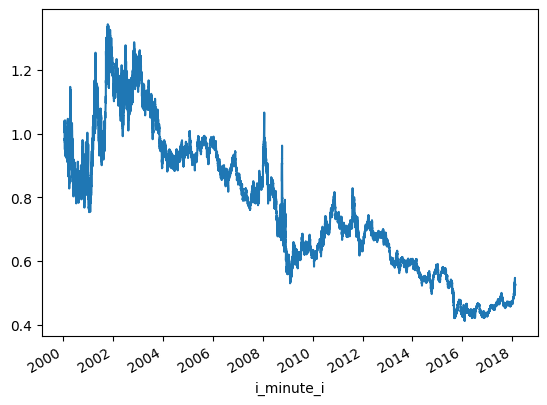

In [182]:
(1 + df_with_signals['RSI_ret_no']).cumprod().plot()

<Axes: xlabel='i_minute_i'>

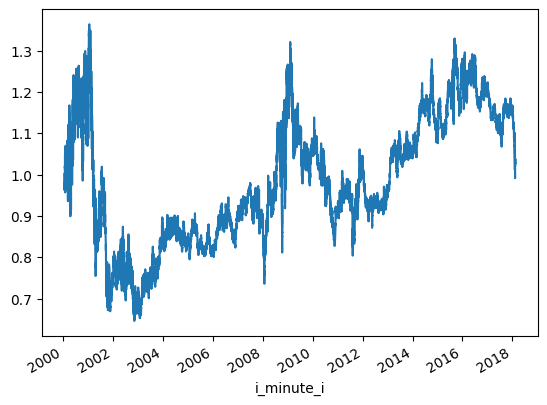

In [173]:
(1 - df_with_signals['Returns']).cumprod().plot()

<Axes: xlabel='i_minute_i'>

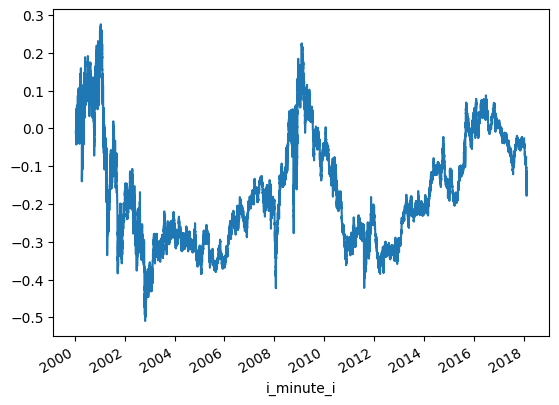

In [162]:
(-df_with_signals['RSI_ret']).cumsum().plot()

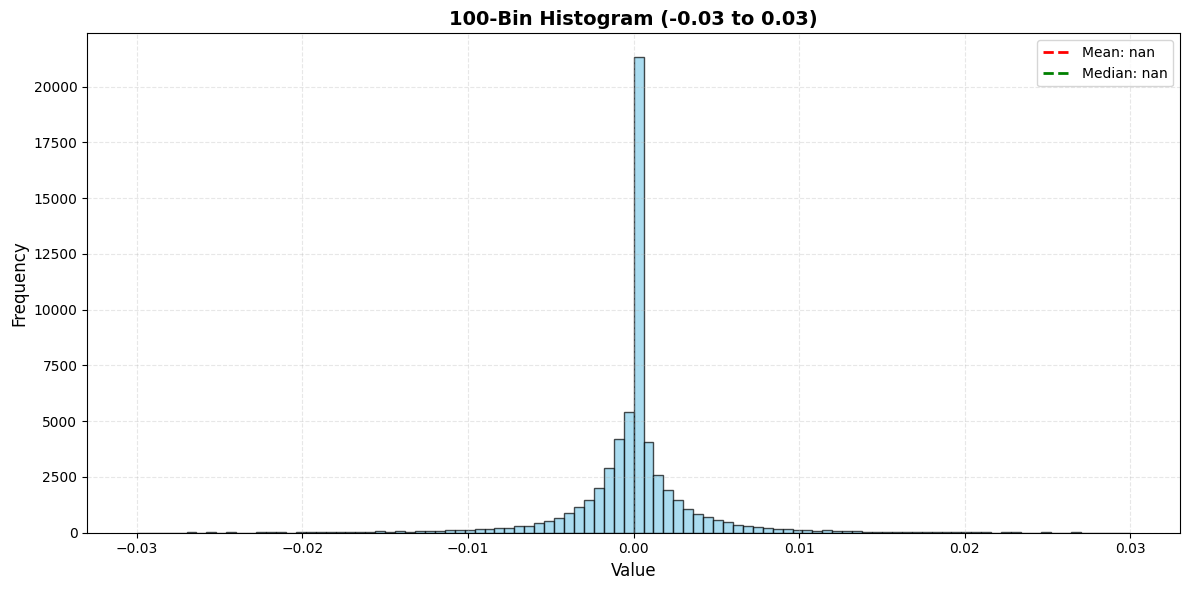

Statistics for values between -0.03 and 0.03:
Mean: nan
Median: nan
Std Dev: nan
Min: nan
Max: nan
Count: 59900


(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': '100-Bin Histogram (-0.03 to 0.03)'}, xlabel='Value', ylabel='Frequency'>)

In [163]:
plot_histogram_100bins(-df_with_signals['RSI_ret'])

<Axes: xlabel='i_minute_i'>

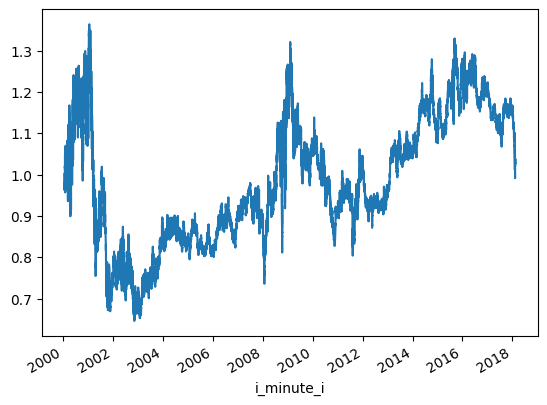

In [164]:
(1-df_with_signals['Returns']).cumprod().plot()

<Axes: xlabel='i_minute_i'>

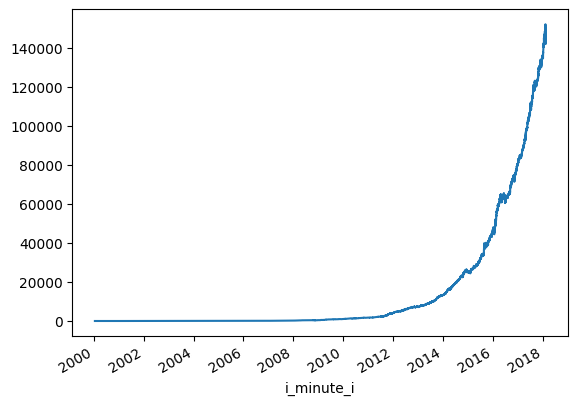

In [149]:
(1-df_with_signals['RSI_ret_no']).cumprod().plot()

<Axes: xlabel='i_minute_i'>

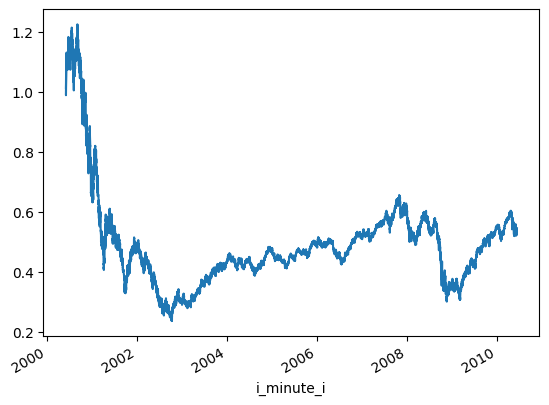

In [142]:
(1+df_with_signals['ReturnsMkt']).cumprod().plot()

<Axes: xlabel='i_minute_i'>

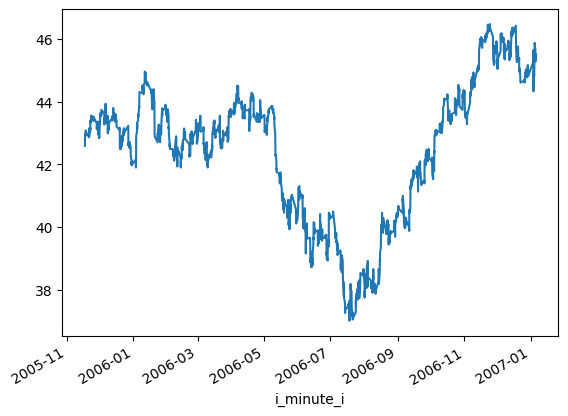

In [122]:
df_with_signals['Close'].plot()

In [136]:
df_with_signals['Close'].pct_change()[2:10].cumprod()

#df_with_signals['Close'].pct_change()[2:10]

i_minute_i
2005-11-17 15:00:00    7.561803e-03
2005-11-18 09:00:00    3.111491e-05
2005-11-18 10:00:00   -1.125367e-07
2005-11-18 11:00:00   -1.090003e-10
2005-11-18 12:00:00    5.259259e-14
2005-11-18 13:00:00    8.899591e-17
2005-11-18 14:00:00   -1.934630e-19
2005-11-18 15:00:00   -4.214687e-22
Name: Close, dtype: float32

<Axes: xlabel='i_minute_i'>

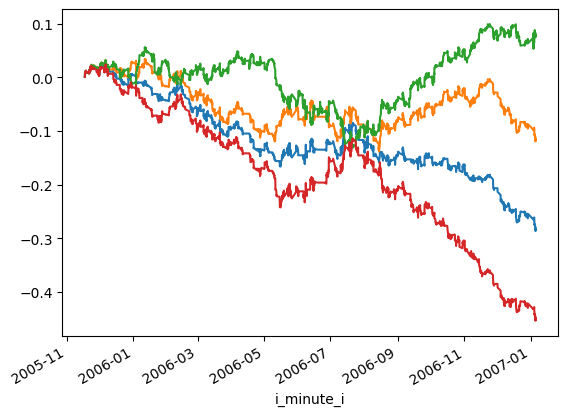

In [117]:
df_with_signals['RSI_ret'].cumsum().plot()
df_with_signals['Returns'].cumsum().plot()
df_with_signals['ReturnsMkt'].cumsum().plot()
df_with_signals['RSI_ret_no'].cumsum().plot()

In [94]:
df_with_signals.columns

Index(['Close', 'Open', 'High', 'Low', 'Volume', 'hl2', 'color', 'Line 1',
       'Line 2', 'Signal', 'Position', 'Returns', 'ReturnsClose', 'rsi_7',
       'rsi_7_signal', 'rsi_14', 'rsi_14_signal', 'rsi_21', 'rsi_21_signal',
       'RSI_ret'],
      dtype='str')

<Axes: xlabel='i_minute_i'>

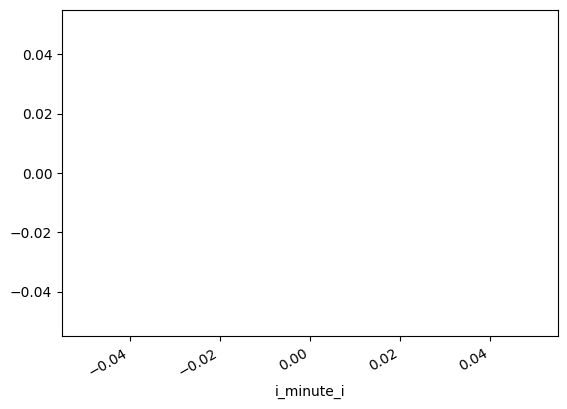

In [101]:
#df_with_signals['rsi_7'].plot()



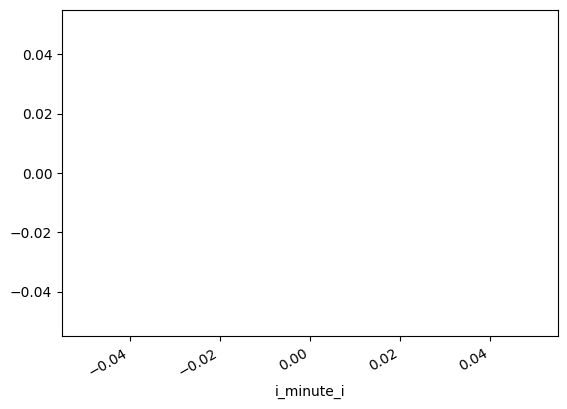

In [90]:


#df_with_signals = calculate_rsi_signals(strat_cto[start:stop], periods=[14, 21])


In [21]:
!pip install datashader geopandas shapely

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 7.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.5/32.5 MB 8.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 8.5 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [22]:
import datashader as ds
import datashader.transfer_functions as tf
import geopandas as gpd
from shapely.geometry import Polygon
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import matplotlib.colors as mcolors

def plot_ribbon_chart_datashader(df, x_label="X-axis", y_label="Y-axis", title="CTO line", 
                                plot_width=3000, plot_height=2000, show_close=True):
    """
    Plots a ribbon chart using datashader from a DataFrame with 'Line 1', 'Line 2', and 'color' columns.
    
    Parameters:
        df (pd.DataFrame): DataFrame with 'Line 1', 'Line 2', and 'color' columns.
        x_label (str): Label for the X-axis.
        y_label (str): Label for the Y-axis.
        title (str): Title of the chart.
        plot_width (int): Width of the canvas in pixels.
        plot_height (int): Height of the canvas in pixels.
        show_close (bool): Whether to overlay the Close line if it exists.
    
    Returns:
        PIL.Image: The rendered image with correct colors
    """
    # Check if required columns exist
    required_columns = {'Line 1', 'Line 2', 'color'}
    if not required_columns.issubset(df.columns):
        raise ValueError(f"DataFrame must contain columns: {required_columns}")
    
    # Convert datetime index to numeric if needed
    if np.issubdtype(df.index.dtype, np.datetime64):
        x_vals = df.index.view("int64")  # nanoseconds
    else:
        x_vals = df.index.values
    
    # Set up coordinate transformation
    x_min, x_max = x_vals.min(), x_vals.max()
    y_min = min(df['Line 1'].min(), df['Line 2'].min())
    y_max = max(df['Line 1'].max(), df['Line 2'].max())
    
    # Add some padding to the y-range
    y_range_padding = (y_max - y_min) * 0.05
    y_min -= y_range_padding
    y_max += y_range_padding
    
    def transform_coords(x, y):
        """Transform data coordinates to pixel coordinates"""
        px = int((x - x_min) / (x_max - x_min) * plot_width)
        py = int((1 - (y - y_min) / (y_max - y_min)) * plot_height)  # Flip y-axis
        return px, py
    
    # Create PIL image
    img = Image.new('RGBA', (plot_width, plot_height), (255, 255, 255, 255))
    draw = ImageDraw.Draw(img)
    
    # Draw ribbons with individual colors
    for i in range(len(df) - 1):
        # Get the four corners of the ribbon segment
        x1, x2 = x_vals[i], x_vals[i+1]
        y1_top, y1_bottom = df['Line 1'].iloc[i], df['Line 2'].iloc[i]
        y2_top, y2_bottom = df['Line 1'].iloc[i+1], df['Line 2'].iloc[i+1]
        
        # Transform to pixel coordinates
        p1 = transform_coords(x1, y1_top)
        p2 = transform_coords(x2, y2_top)
        p3 = transform_coords(x2, y2_bottom)
        p4 = transform_coords(x1, y1_bottom)
        
        # Get color for this segment
        color = df['color'].iloc[i]
        
        # Convert color to RGB if it's a hex string or named color
        try:
            if isinstance(color, str):
                if color.startswith('#'):
                    # Hex color
                    rgb_color = tuple(int(color[j:j+2], 16) for j in (1, 3, 5))
                else:
                    # Named color
                    rgb_color = mcolors.to_rgb(color)
                    rgb_color = tuple(int(c * 255) for c in rgb_color)
            else:
                # Assume it's already RGB
                rgb_color = tuple(int(c * 255) if c <= 1 else int(c) for c in color[:3])
        except:
            # Default to blue if color conversion fails
            rgb_color = (0, 100, 200)
        
        # Add alpha for transparency
        rgba_color = rgb_color + (153,)  # alpha=0.6 * 255
        
        # Draw the polygon
        polygon_points = [p1, p2, p3, p4]
        draw.polygon(polygon_points, fill=rgba_color)
    
    # Overlay Close line if requested
    if show_close and 'Close' in df.columns:
        close_points = []
        for i, close_val in enumerate(df['Close']):
            if not pd.isna(close_val):
                px, py = transform_coords(x_vals[i], close_val)
                close_points.append((px, py))
        
        # Draw the close line
        if len(close_points) > 1:
            for i in range(len(close_points) - 1):
                draw.line([close_points[i], close_points[i+1]], fill=(0, 0, 0, 255), width=2)
    
    return img

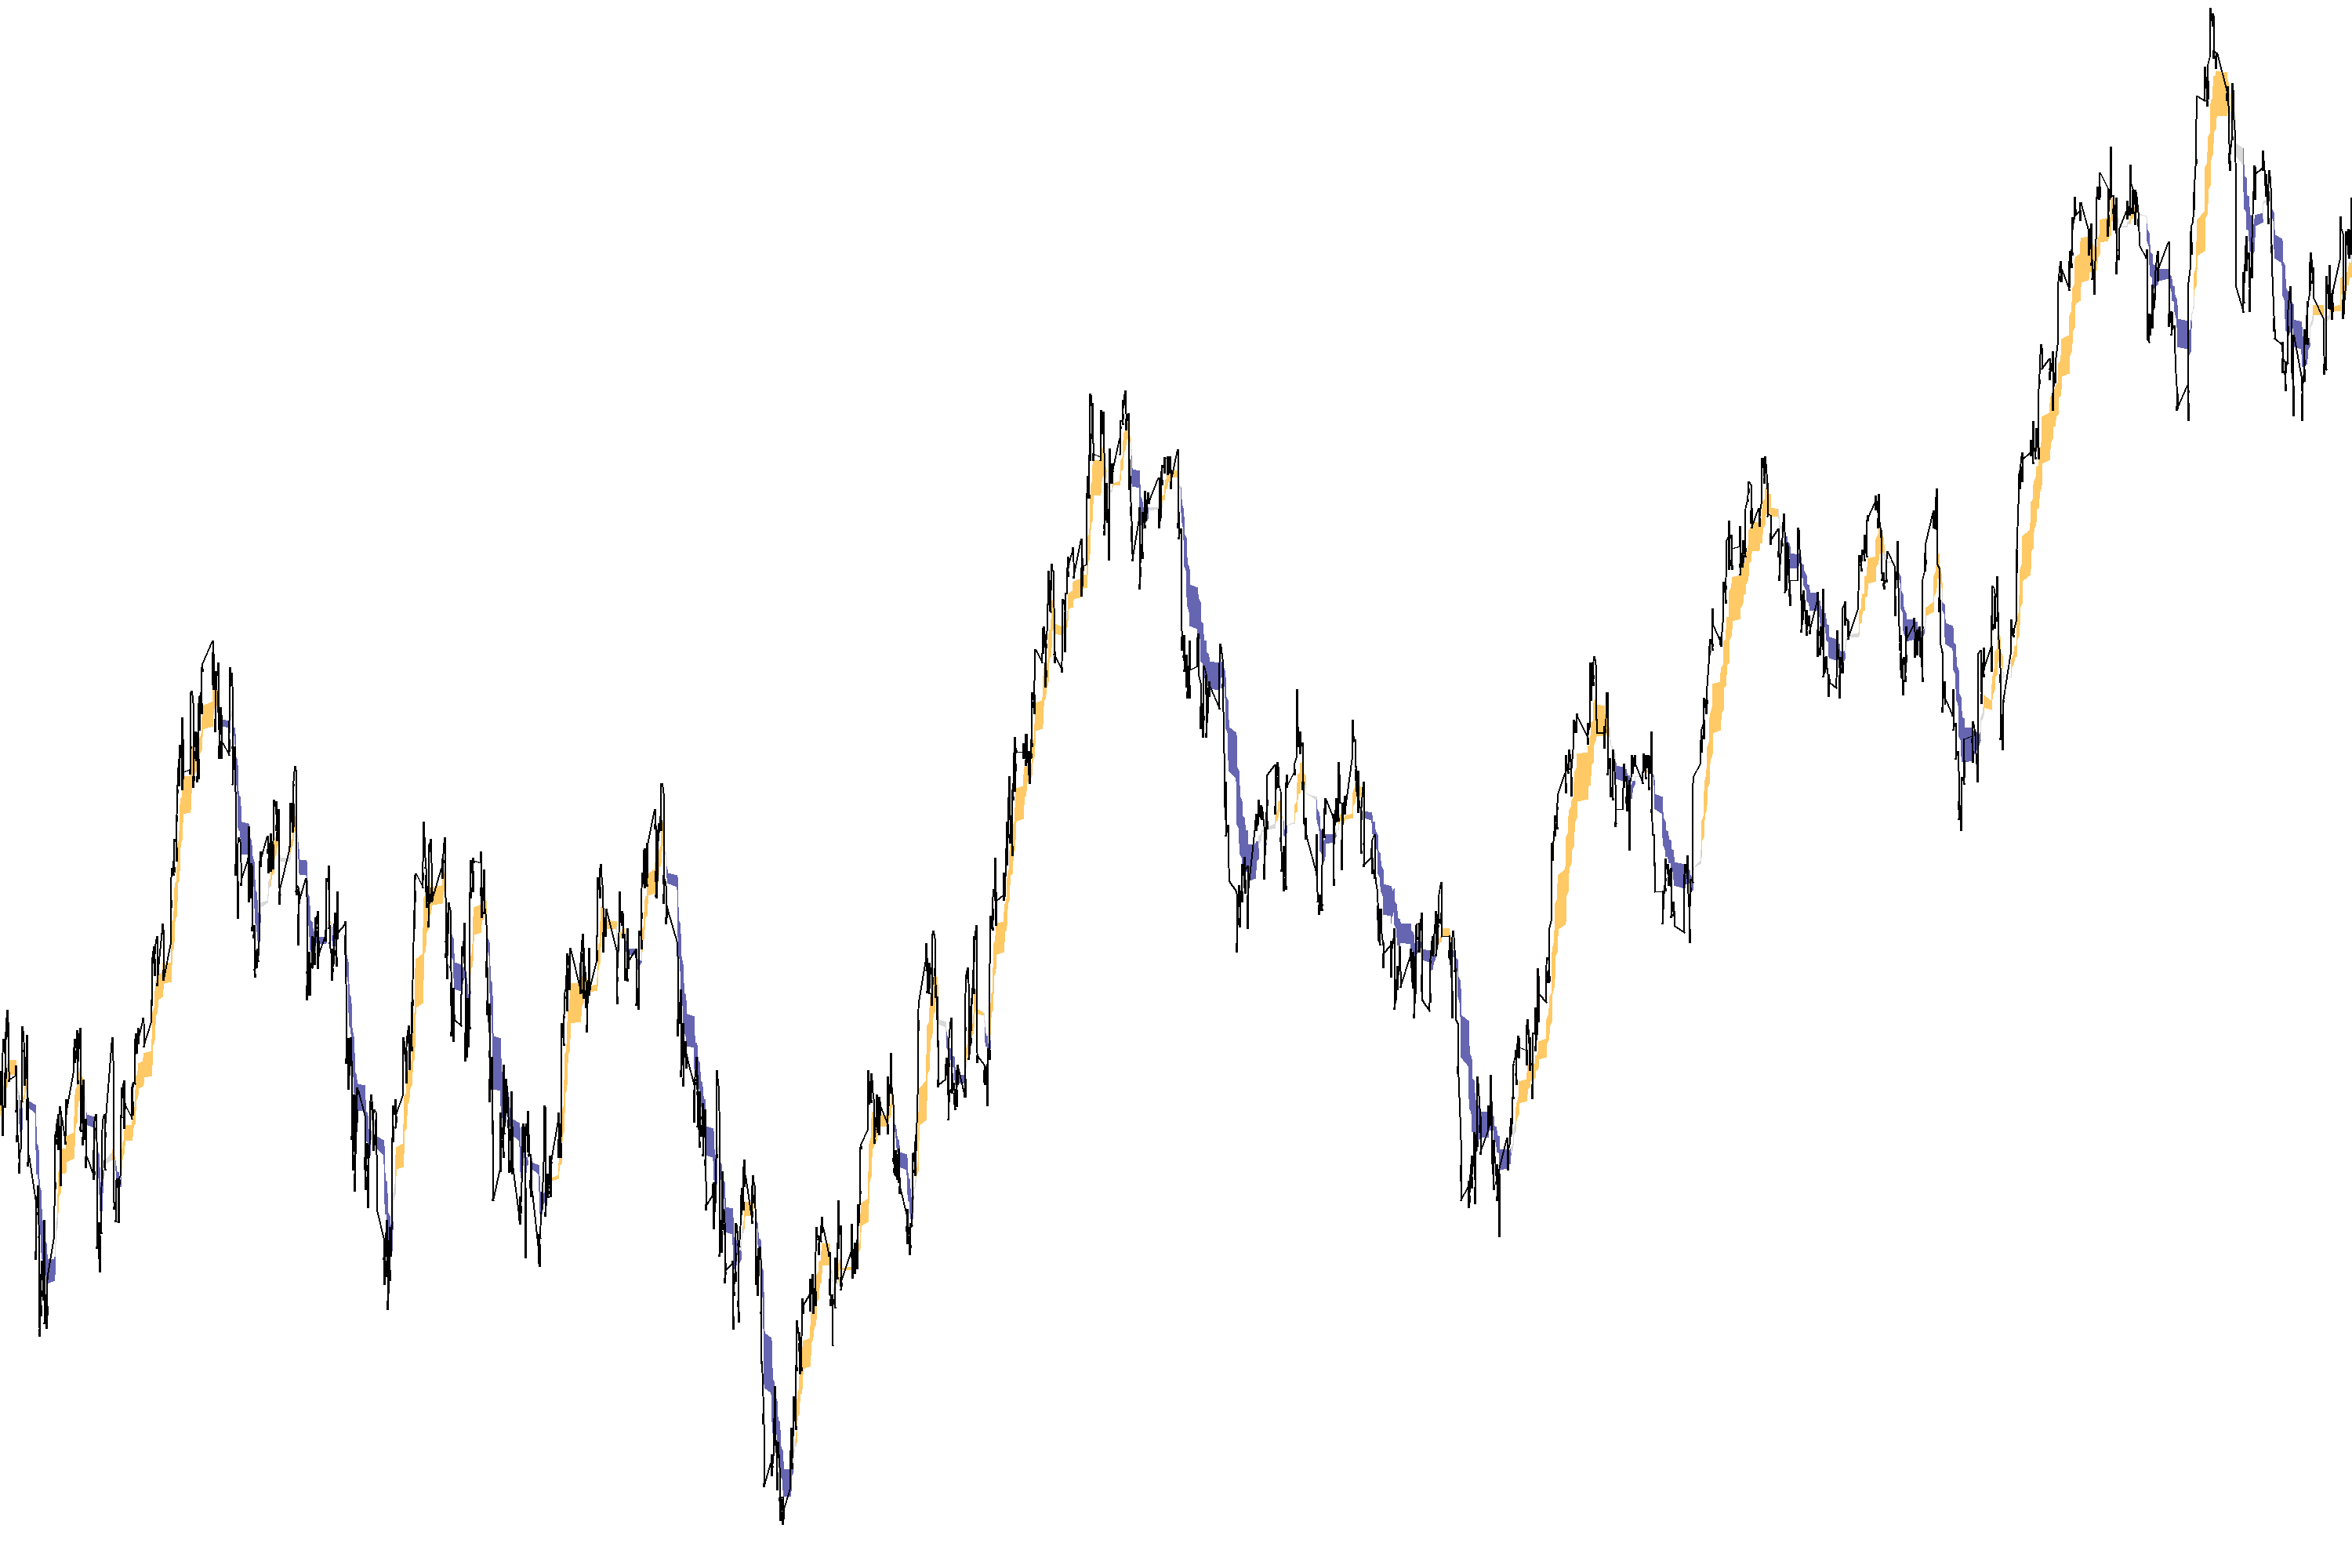

In [24]:
plot_ribbon_chart_datashader(strat_cto[10000:15500])

In [ ]:
def display_ribbon_chart(img, title="CTO line", x_label="X-axis", y_label="Y-axis"):
    """
    Display the ribbon chart image with matplotlib for proper labeling.
    
    Parameters:
        img: PIL Image object
        title (str): Title of the chart
        x_label (str): Label for the X-axis
        y_label (str): Label for the Y-axis
    """
    fig, ax = plt.subplots(figsize=(14, 10))
    ax.imshow(img)
    ax.set_title(title, fontsize=16)
    ax.set_xlabel(x_label, fontsize=12)
    ax.set_ylabel(y_label, fontsize=12)
    ax.set_xticks([])  # Remove ticks since we handle the data visualization
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()